# Miscellaneous Results and Figures from:
## Entanglement generation and characterization using metamaterial resonators

Alessandro S. Santana

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from IPython.display import clear_output
from numpy import *
from qutip import *
from IPython.display import Image
from numpy.linalg import *
import multiprocessing  
from multiprocessing import Pool, cpu_count
import scipy.constants as sc
import time
import datetime
import os
from matplotlib import cm
import matplotlib as mpl
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})
plt.rcParams['axes.linewidth'] = 1.5 #set the value globally
plt.rcParams['figure.dpi'] = 100

ls = 30.0   # tick label size
fs = 30.0   # axis label size

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # ===== Fonts =====
    "font.size": 30,
    "axes.labelsize": fs,
    "axes.titlesize": 30,
    # ===== Lines =====
    "lines.linewidth": 2.5,
    # ===== Ticks =====
    "xtick.labelsize": ls,
    "ytick.labelsize": ls,
    "xtick.direction": "in",  
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    # Tick size 
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    # ===== Axes =====
    "axes.linewidth": 2.5,
    "axes.grid": False, 
    # ===== Legend =====
    "legend.frameon": False,
    "legend.fontsize": 15,
    # ===== Figure =====
    "figure.figsize": (16, 6),
    "figure.dpi": 100
})

saveResults = True

## Model

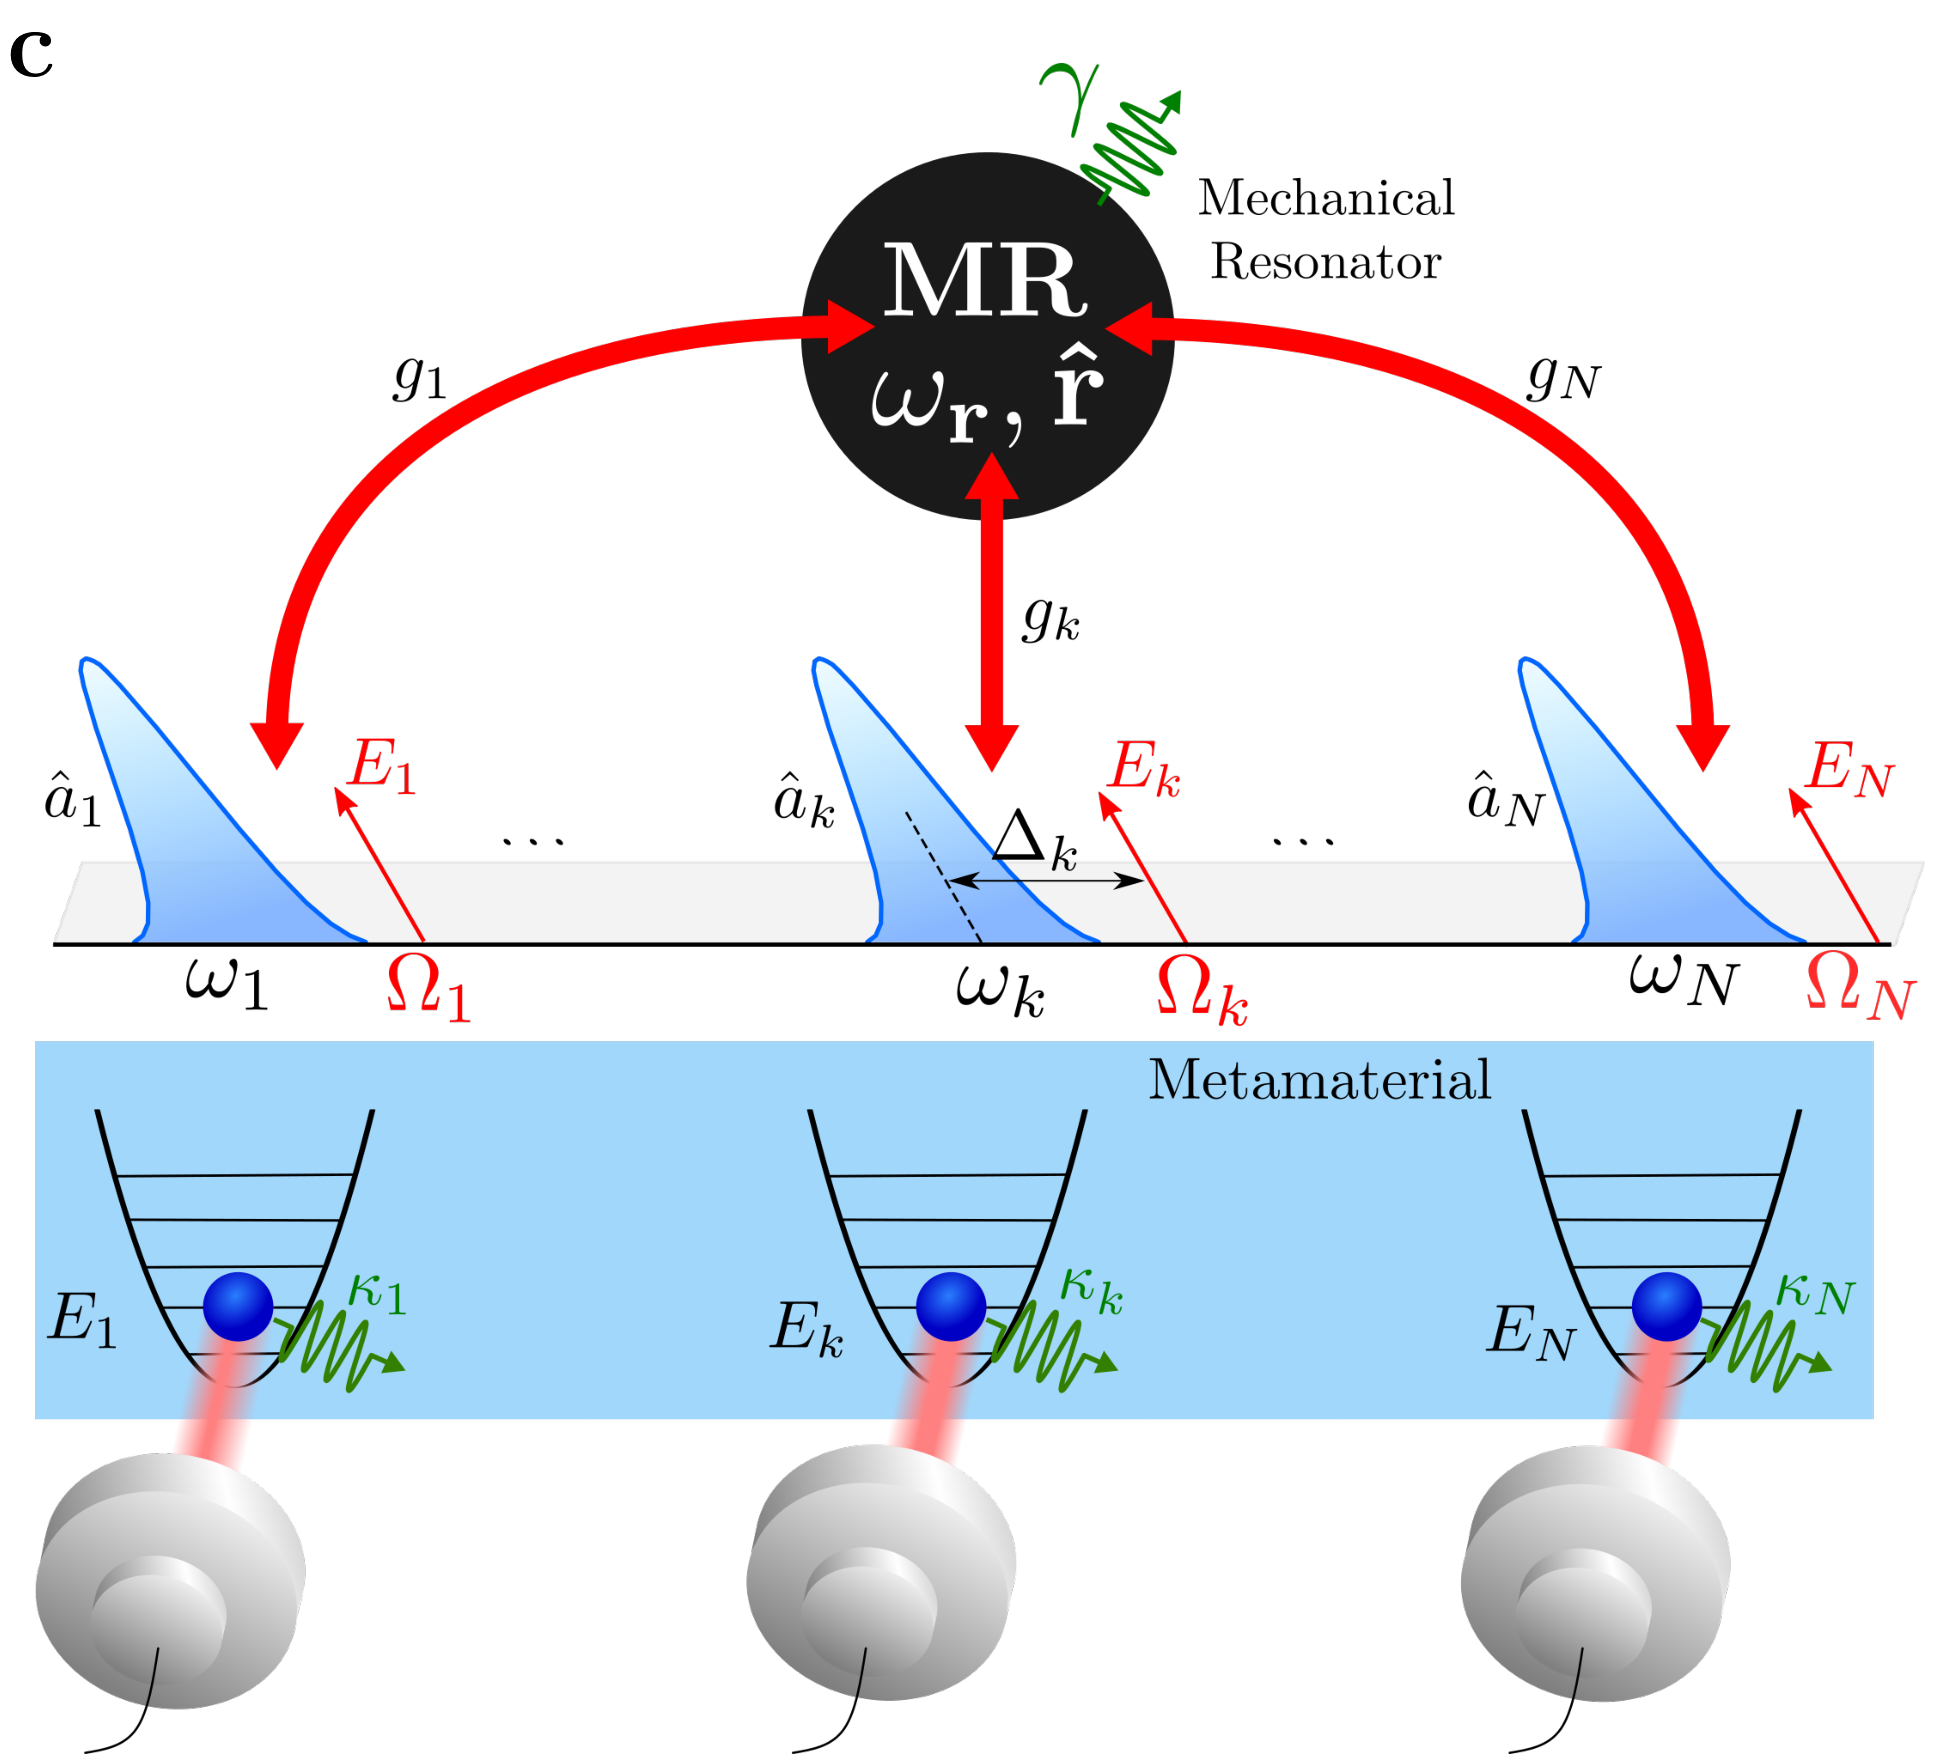

In [2]:
fig, axes = plt.subplots(1, 1, figsize=(20, 20))

img3 = mpimg.imread(r'Images\Metamaterial_MR_system_schematic.png')

axes.text(-30, 15, r"$\mathbf{c}$", color='black', fontsize=70)

plt.axis('off')
plt.imshow(img3)
plt.tight_layout()
if(saveResults == True):
    plt.savefig(r'Results/fig03_Metamaterial_MR_system_schematic_pdf.pdf')
    plt.savefig(r'Results/fig03_Metamaterial_MR_system_schematic_png.png')
plt.show()

## Metamaterial Circuit Resonator

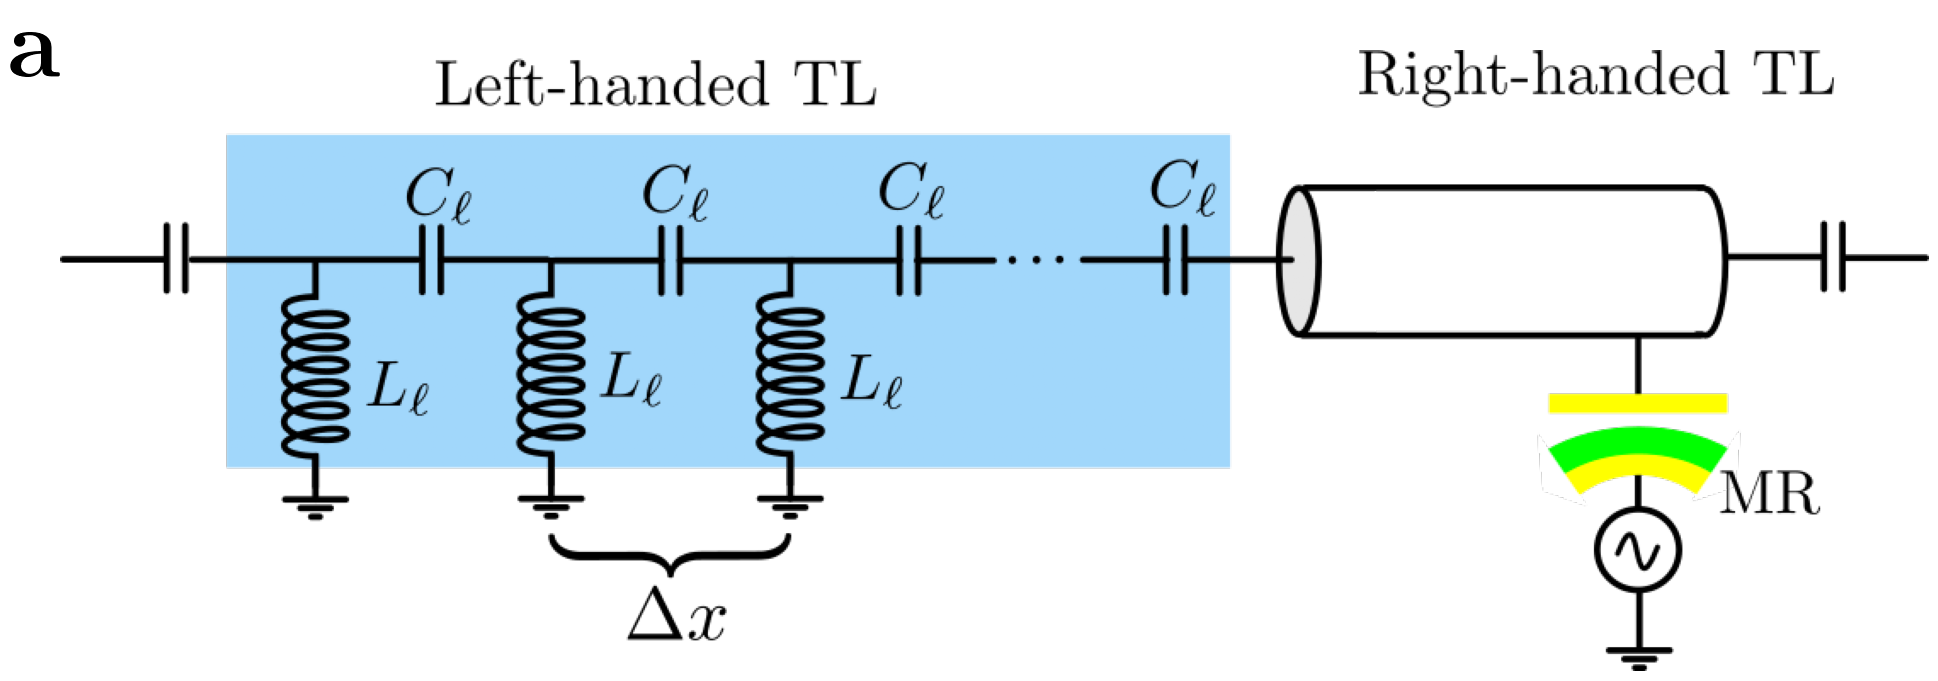

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(20, 20))

img1 = mpimg.imread(r'Images\CTL_MechanicResonator_circuit_model.png')

axes.text(-30, 15, r"$\mathbf{a}$", color='black', fontsize=70)

plt.axis('off')
plt.imshow(img1)
plt.tight_layout()
if(saveResults == True):
    plt.savefig(r'Results/fig01_CTL_MechanicResonator_circuit_model_pdf.pdf')
    plt.savefig(r'Results/fig01_CTL_MechanicResonator_circuit_model_png.png')
plt.show()

In [4]:
characteristic_Impedance = 50  # Ohm
infrared_cutoff = 2 * pi * 5 * 1e9  # 5 GHz

capacitance_per_cell = (1 / (2 * infrared_cutoff * characteristic_Impedance))
inductance_per_cell = (characteristic_Impedance / (2 * infrared_cutoff))

print('Capacitance (C) = %.3f fF/cell' % (capacitance_per_cell*1e15))
print('Inductance (L) = %.3f pH/cell' % (inductance_per_cell*1e12))

Capacitance (C) = 318.310 fF/cell
Inductance (L) = 795.775 pH/cell


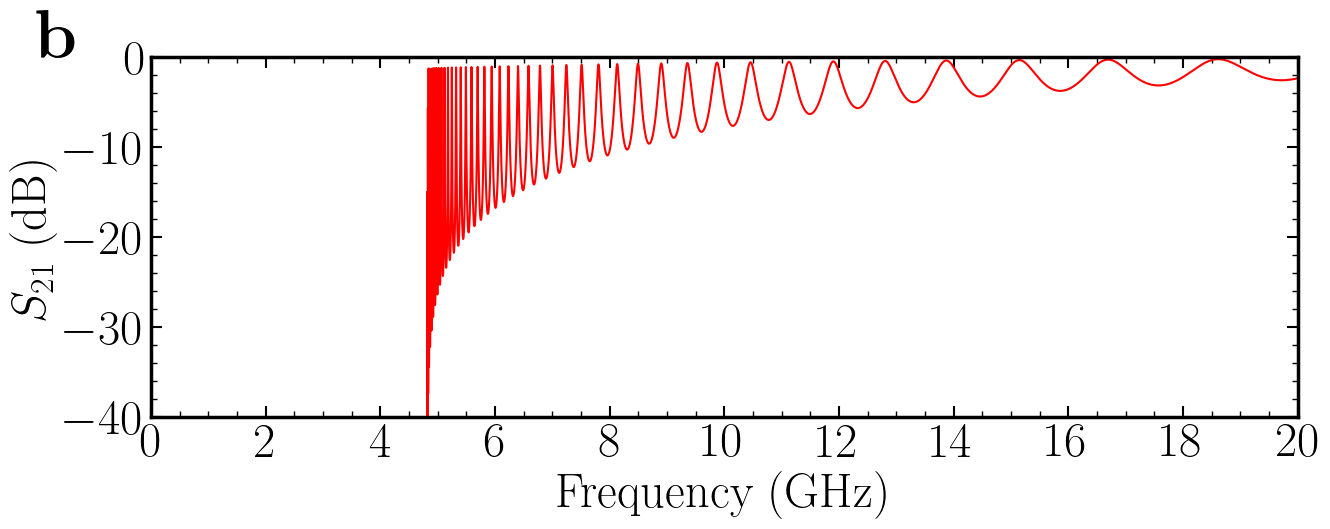

In [5]:
data_s21_artigo = loadtxt(r'Data/S21parameter_cutoff5GHz.txt')

x_list_s21artigo = data_s21_artigo[:,0]
y_list_s21artigo = data_s21_artigo[:,1]

fig, axes1 = plt.subplots(1, 1, figsize=(14, 6)) #14,7

axes1.plot(x_list_s21artigo, y_list_s21artigo, color='red', linestyle='-', label=r'Delta', lw=1.5)

axes1.set_xlabel(r'Frequency (GHz)', rotation=0, fontsize=35)
axes1.set_ylabel(
    r'$S_{21}$ (dB)', rotation=90, fontsize=35)

axes1.tick_params(axis='both', which='major', length = 8, direction='in', labelsize=35)
axes1.tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=35)
#axes1.yaxis.tick_right()
axes1.xaxis.set_ticks_position('both')
axes1.yaxis.set_ticks_position('both')
#axes1.legend(loc=2, fontsize=23, frameon=False)

#axes1.set_xlim(0, 5778.04)
axes1.set_ylim(-40, 0)
axes1.set_xlim(0, 20)

start, end = axes1.get_ylim()
axes1.xaxis.set_ticks(arange(0, 20+1, 2))
axes1.yaxis.set_ticks(arange(start, end+1, 10))

axes1.xaxis.set_minor_locator(AutoMinorLocator())
axes1.yaxis.set_minor_locator(AutoMinorLocator())

axes1.set_ylim(-40, 0)
axes1.set_xlim(0, 20)

axes1.text(-2, 0, r"$\mathbf{b}$", color='black', fontsize=50)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()

if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

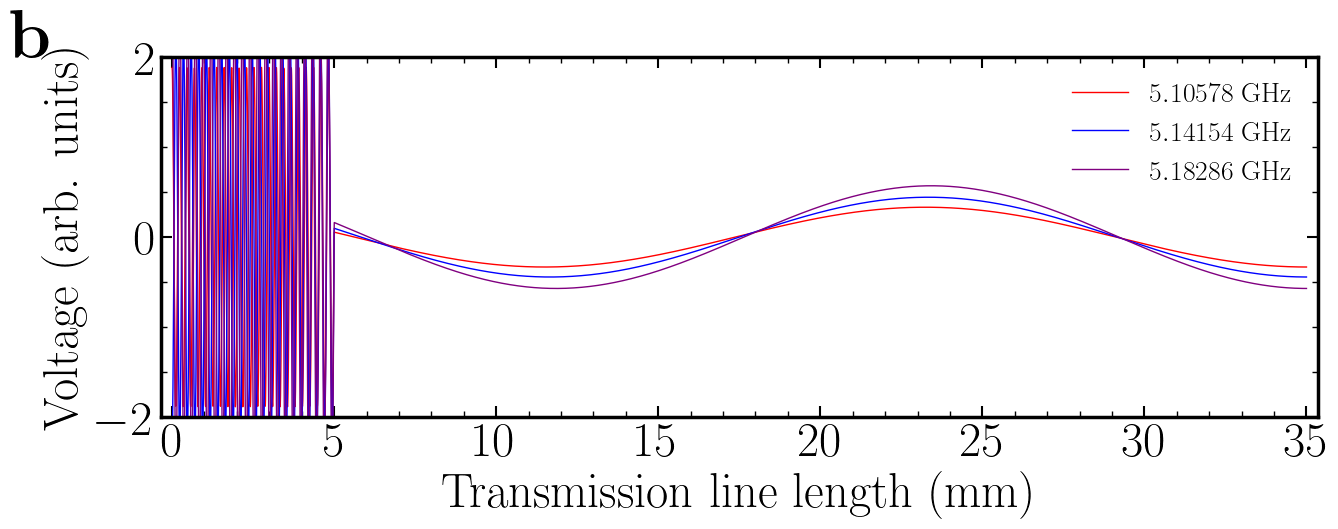

In [6]:
###############################
# Parameters from Mathematica calcultations
# Right-handed capacitance per unit of length = 0.1667 fF/um
# Right-handed inductance per unit of length = 0.4167 pH/um
# Left-handed capacitance = 318.310 fF
# Left-handed inductance  = 795.775 pH
# Number of unit cells = 50
# Unit cell length = Delta x = 100 um
# Right-handed TL length = 30 mm 
###############################

data_voltageMode1_fromMathematica = loadtxt(r'Data\data1_freq5105779.txt')
data_voltageMode2_fromMathematica = loadtxt(r'Data\data2_freq5141539.txt')
data_voltageMode3_fromMathematica = loadtxt(r'Data\data3_freq5182859.txt')

x1_list_length = data_voltageMode1_fromMathematica[:,0]*1000 + 5
y1_list_voltage = data_voltageMode1_fromMathematica[:,1]

x2_list_length = data_voltageMode2_fromMathematica[:,0]*1000  + 5
y2_list_voltage = data_voltageMode2_fromMathematica[:,1]

x3_list_length = data_voltageMode3_fromMathematica[:,0]*1000 + 5
y3_list_voltage = data_voltageMode3_fromMathematica[:,1]

fig, axes = plt.subplots(1, 1, figsize=(14, 6)) #14,7

axes.plot(x1_list_length, y1_list_voltage, color='red', linestyle='-', label=r'$5.10578$ GHz', lw=1.)
axes.plot(x2_list_length, y2_list_voltage, color='blue', linestyle='-', label=r'$5.14154$ GHz', lw=1.)
axes.plot(x3_list_length, y3_list_voltage, color='purple', linestyle='-', label=r'$5.18286$ GHz', lw=1.)

axes.set_xlabel(r'Transmission line length (mm)', rotation=0, fontsize=35)
axes.set_ylabel(r'Voltage (arb. units)', rotation=90, fontsize=35)

axes.tick_params(axis='both', which='major', length = 8, direction='in', labelsize=35)
axes.tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=35)
#axes.yaxis.tick_right()
axes.xaxis.set_ticks_position('both')
axes.yaxis.set_ticks_position('both')
#axes.legend(loc=2, fontsize=23, frameon=False)

#axes.set_xlim(0, 5778.04)
#axes.set_ylim(-40, 0)
axes.set_ylim(-2, 2)

#start, end = axes.get_ylim()
axes.xaxis.set_ticks(arange(0, 35+1, 5))
#axes.yaxis.set_ticks(arange(start, end+1, 10))

axes.xaxis.set_minor_locator(AutoMinorLocator())
axes.yaxis.set_minor_locator(AutoMinorLocator())

#axes.set_ylim(-40, 0)
#axes.set_xlim(0, 20)

axes.text(-5, 2, r"$\mathbf{b}$", color='black', fontsize=50)
#axes.text(-5, -1.5, r"Right-handed", color='black', fontsize=30)
#axes.text(10, -1.5, r"Left-handed", color='black', fontsize=30)


axes.legend(loc=1,fontsize=20,frameon=False)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()



if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

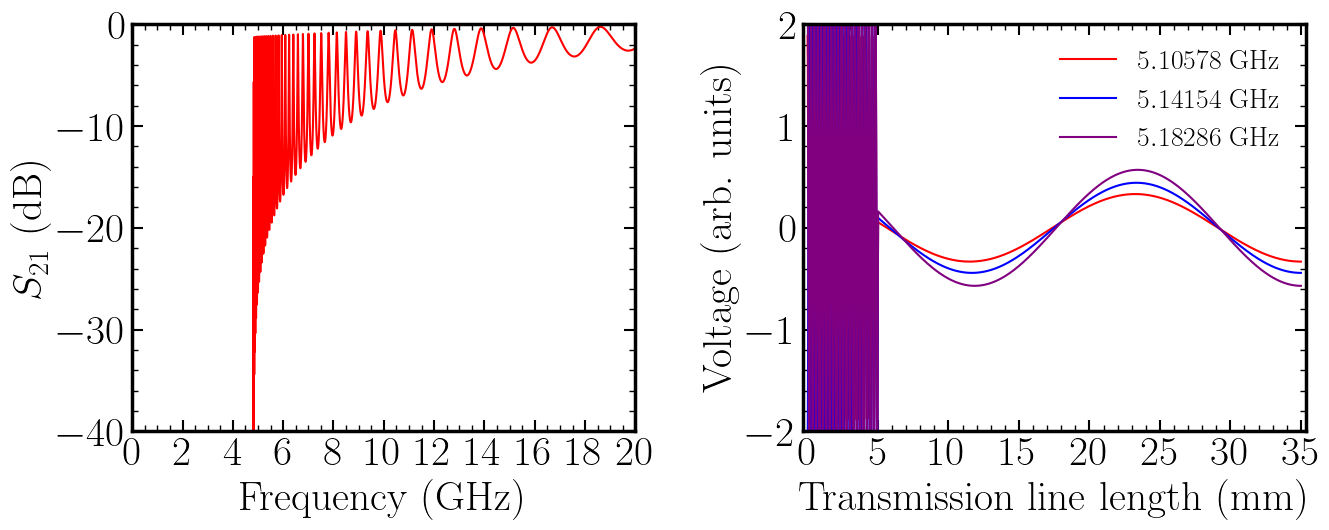

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

axes[0].plot(x_list_s21artigo, y_list_s21artigo, color='red', linestyle='-', label=r'Delta', lw=1.5)

axes[0].set_xlabel(r'Frequency (GHz)', rotation=0, fontsize=30)
axes[0].set_ylabel(
    r'$S_{21}$ (dB)', rotation=90, fontsize=30)

axes[0].tick_params(axis='both', which='major', length = 8, direction='in', labelsize=30)
axes[0].tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=30)
#axes.yaxis.tick_right()
axes[0].xaxis.set_ticks_position('both')
axes[0].yaxis.set_ticks_position('both')
#axes.legend(loc=2, fontsize=23, frameon=False)

#axes.set_xlim(0, 5778.04)
axes[0].set_ylim(-40, 0)
axes[0].set_xlim(0, 20)

start, end = axes[0].get_ylim()
axes[0].xaxis.set_ticks(arange(0, 20+1, 2))
axes[0].yaxis.set_ticks(arange(start, end+1, 10))

axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0].set_ylim(-40, 0)
axes[0].set_xlim(0, 20)

#axes.text(-2, 0, r"$\mathbf{b}$", color='black', fontsize=50)

axes[1].plot(x1_list_length, y1_list_voltage, color='red', linestyle='-', label=r'$5.10578$ GHz', lw=1.5)
axes[1].plot(x2_list_length, y2_list_voltage, color='blue', linestyle='-', label=r'$5.14154$ GHz', lw=1.5)
axes[1].plot(x3_list_length, y3_list_voltage, color='purple', linestyle='-', label=r'$5.18286$ GHz', lw=1.5)

axes[1].set_xlabel(r'Transmission line length (mm)', rotation=0, fontsize=30)
axes[1].set_ylabel(r'Voltage (arb. units)', rotation=90, fontsize=30)

axes[1].tick_params(axis='both', which='major', length = 8, direction='in', labelsize=30)
axes[1].tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=30)
#axes[1].yaxis.tick_right()
axes[1].xaxis.set_ticks_position('both')
axes[1].yaxis.set_ticks_position('both')
#axes[1].legend(loc=2, fontsize=23, frameon=False)

#axes[1].set_xlim(0, 5778.04)
#axes[1].set_ylim(-40, 0)
axes[1].set_ylim(-2, 2)

#start, end = axes[1].get_ylim()
axes[1].xaxis.set_ticks(arange(0, 35+1, 5))
#axes[1].yaxis.set_ticks(arange(start, end+1, 10))

axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator())

#axes[1].set_ylim(-40, 0)
#axes[1].set_xlim(0, 20)

#axes[1].text(-10, 2, r"$\mathbf{b}$", color='black', fontsize=50)
#axes[1].text(-5, -1.5, r"Right-handed", color='black', fontsize=30)
#axes[1].text(10, -1.5, r"Left-handed", color='black', fontsize=30)


axes[1].legend(loc=1,fontsize=20,frameon=False)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()

if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

## Temperature and Dimension Test

In [9]:
w_test1 = 2 * pi * 10 * 1e6   # Test frequency = 10 MHz
w_test2 = 2 * pi * 20 * 1e6   # Test frequency = 20 MHz
w_test3 = 2 * pi * 50 * 1e6   # Test frequency = 50 MHz
w_test4 = 2 * pi * 100 * 1e6  # Test frequency = 100 MHz

w_test5 = 2 * pi * 1 * 1e9  # Test frequency = 1 GHz
w_test6 = 2 * pi * 5 * 1e9  # Test frequency = 5 GHz

test_frequencies = [w_test1, w_test2, w_test3, w_test4, w_test5, w_test6]

test_temperatures = linspace(0.001, 0.1, 200) 
test_dimensions = arange(3,16,1)                        

list_exc0_temp_vs_dim_freq = []
list_exc1_temp_vs_dim_freq = []
list_exc2_temp_vs_dim_freq = []
list_exc3_temp_vs_dim_freq = []
list_exc4_temp_vs_dim_freq = []

for k in test_frequencies:
    list_exc0_temp_vs_dim = []
    list_exc1_temp_vs_dim = []
    list_exc2_temp_vs_dim = []
    list_exc3_temp_vs_dim = []
    list_exc4_temp_vs_dim = []
    for i in test_temperatures:
        list_exc0_dim = []
        list_exc1_dim = []
        list_exc2_dim = []
        list_exc3_dim = []
        list_exc4_dim = [] 
        for l in test_dimensions:
            w_th = (sc.k*i)/(sc.hbar)
            n_th = n_thermal(k, w_th)
            list_exc0_dim.append(real(thermal_dm(l, n_th)[0,0]))
            list_exc1_dim.append(real(thermal_dm(l, n_th)[1,1]))
            list_exc2_dim.append(real(thermal_dm(l, n_th)[2,2]))
            if l > 3:
                list_exc3_dim.append(real(thermal_dm(l, n_th)[3,3]))
                if l > 4:
                    list_exc4_dim.append(real(thermal_dm(l, n_th)[4,4]))
                else:
                    list_exc4_dim.append(0)
            else:
                list_exc3_dim.append(0)
                list_exc4_dim.append(0)

        list_exc0_temp_vs_dim.append(list_exc0_dim)
        list_exc1_temp_vs_dim.append(list_exc1_dim)
        list_exc2_temp_vs_dim.append(list_exc2_dim)
        list_exc3_temp_vs_dim.append(list_exc3_dim)
        list_exc4_temp_vs_dim.append(list_exc4_dim)
    list_exc0_temp_vs_dim_freq.append(list_exc0_temp_vs_dim)
    list_exc1_temp_vs_dim_freq.append(list_exc1_temp_vs_dim)
    list_exc2_temp_vs_dim_freq.append(list_exc2_temp_vs_dim)
    list_exc3_temp_vs_dim_freq.append(list_exc3_temp_vs_dim)
    list_exc4_temp_vs_dim_freq.append(list_exc4_temp_vs_dim)

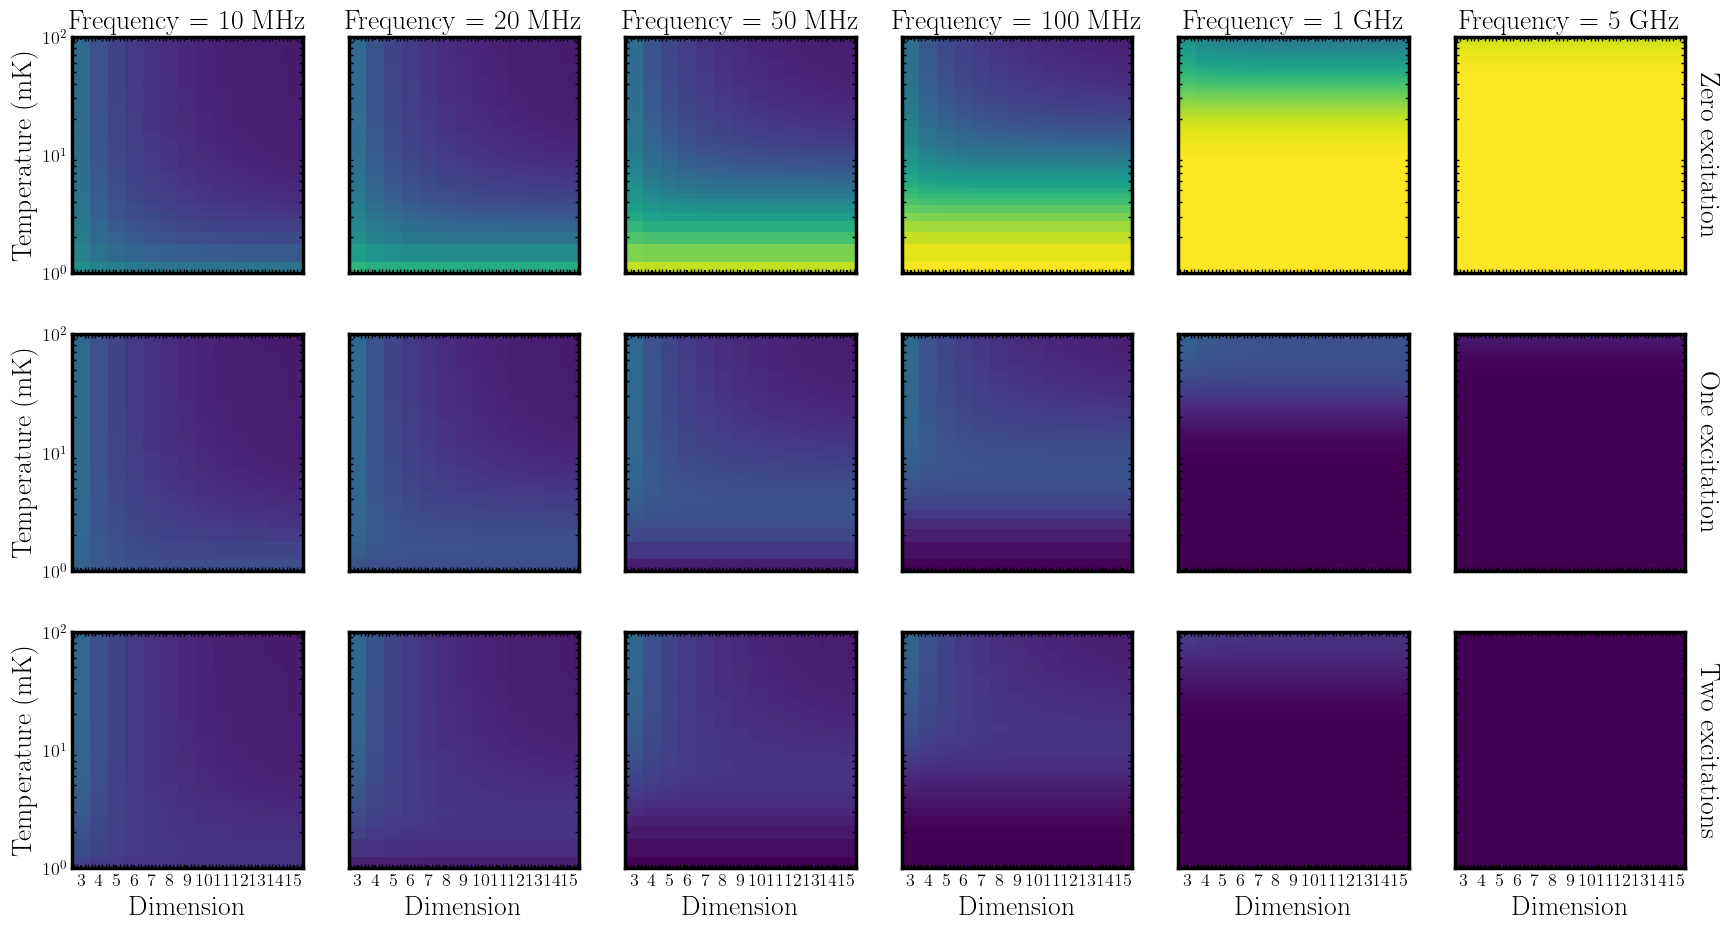

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10),sharey=True,sharex=True)

Lsize = 20

nrm = mpl.colors.Normalize(0, 1)

########################
# Use 'norm = nrm' below to normalize the probability colormap from 0 to 1. Otherwise, 
# use 'norm = nrm1' (or 'norm = nrm2' or 'norm = nrm3', depending on the excitation) to
# normalize the colomap according to the local maximum.
########################

for k in range(0,len(test_frequencies)):
    nrm1 = mpl.colors.Normalize(0, max(list_exc0_temp_vs_dim_freq[k][0]))
    axes[0,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc0_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[0,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[0,5].yaxis.set_label_position("right")
    axes[0,5].set_ylabel(r'Zero excitation', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[0,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[0,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[0,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[0,k].yaxis.set_ticks_position('both')
    axes[0,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[0,k].xaxis.set_tick_params(length=2)
    axes[0,k].yaxis.set_tick_params(length=1)
    axes[0,k].set_ylim(1,100)

    nrm2 = mpl.colors.Normalize(0, max(list_exc1_temp_vs_dim_freq[k][-1]))
    axes[1,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc1_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[1,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[1,5].yaxis.set_label_position("right")
    axes[1,5].set_ylabel(r'One excitation', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[1,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[1,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[1,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[1,k].yaxis.set_ticks_position('both')
    axes[1,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[1,k].xaxis.set_tick_params(length=2)
    axes[1,k].yaxis.set_tick_params(length=1)
    axes[1,k].set_yscale('log')
    axes[1,k].set_ylim(1,100)

    nrm3 = mpl.colors.Normalize(0, max(list_exc2_temp_vs_dim_freq[k][-1]))
    axes[2,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc2_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[2,k].set_xlabel(r'Dimension', rotation=0, fontsize=Lsize)
    axes[2,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[2,5].yaxis.set_label_position("right")
    axes[2,5].set_ylabel(r'Two excitations', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[2,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[2,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[2,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[2,k].yaxis.set_ticks_position('both')
    axes[2,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[2,k].xaxis.set_tick_params(length=2)
    axes[2,k].yaxis.set_tick_params(length=1)
    axes[2,k].set_yscale('log')
    axes[2,k].set_ylim(1,100)
    
axes[0,0].set_title(r'Frequency = 10 MHz', fontsize=Lsize)
axes[0,1].set_title(r'Frequency = 20 MHz', fontsize=Lsize)
axes[0,2].set_title(r'Frequency = 50 MHz', fontsize=Lsize)
axes[0,3].set_title(r'Frequency = 100 MHz', fontsize=Lsize)
axes[0,4].set_title(r'Frequency = 1 GHz', fontsize=Lsize)
axes[0,5].set_title(r'Frequency = 5 GHz', fontsize=Lsize)

plt.tight_layout()
plt.show()


## Blockade Regime Range of parameters

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# ======================================================================================
# Parameters
# ======================================================================================

omega_r_list = [10, 50, 100, 1000]   # MHz

#kappa_1_list = np.logspace(-3, 1, 500)   # MHz
#g_1_list     = np.logspace(-2, 4, 500)   # MHz

kappa_1_list = np.logspace(-4, 5.5, 600)   # MHz
g_1_list     = np.logspace(-7, 4, 600)   # MHz

KAPPA_1, G_1 = np.meshgrid(kappa_1_list, g_1_list)

chosen_points = [
    #{
    #    "kappa_1": 0.08,
    #    "g_1": 5.0,
    #    "label": " ",
    #    "color": "black",
    #    "marker": "o"
    #},

    # Same linewidth scale
    {
        "kappa_1": 0.20,
        "g_1": 2e-4,
        "label": "Teufel 2011",
        "color": "tab:blue",
        "marker": "s"
    },
    {
        "kappa_1": 0.0455,
        "g_1": 3.6e-7,
        "label": "Yuan 2015",
        "color": "tab:cyan",
        "marker": "v"
    },
    {
        "kappa_1": 0.38,
        "g_1": 0.0036,
        "label": "Bothner 2022",
        "color": "tab:purple",
        "marker": "D"
    },

     #Same coupling scale
    {
        "kappa_1": 8.0,
        "g_1": 0.160,
        "label": "Bera 2024",
        "color": "tab:red",
        "marker": "o",
        "rotation": 15
    },
    {
        "kappa_1": 255.0,
        "g_1": 1.08,
        "label": "Qiu 2020",
        "color": "tab:orange",
        "marker": "^"
    },
    {
        "kappa_1": 2400.0,
        "g_1": 1.0,
        "label": "Chen 2026",
        "color": "tab:green",
        "marker": "P"
    }
]
chosen_regions = [
    {
        "kappa_min": 0.05,   # 20 kHz = 0.05 MHz
        "kappa_max": 0.20,   # 500 kHz = 0.20 MHz
        "g_min": 0.50,       # 10 kHz = 0.10 MHz
        "g_max": 15.0,       # 15 MHz
        "label": "Simulation parameters",
        "edgecolor": "black",
        "facecolor": "none",
        "alpha": 0.9,
        "linestyle": ":",
        "linewidth": 1.8
    }
]

# Constant blockade-ratio lines
ratio_values = [1e-3, 1e-2, 1e-1, 1, 10, 100]

save_folder = "Results_Blockade_Regime"
os.makedirs(save_folder, exist_ok=True)

# ======================================================================================
# Helper functions
# ======================================================================================

def g_from_ratio(kappa_vals, omega_r, ratio):
    """
    ratio = (2 g_1^2 / omega_r) / kappa_1
    => g_1 = sqrt(ratio * omega_r * kappa_1 / 2)
    """
    return np.sqrt(ratio * omega_r * kappa_vals / 2.0)


def add_ratio_line_labels(ax, omega_r, ratio_values, x_positions,
                          color_regular="maroon", color_boundary="darkgreen"):
    """
    Put a label directly on each R_B line.
    x_positions should have same length as ratio_values or more.
    """

    ymin, ymax = ax.get_ylim()

    for i, R in enumerate(ratio_values):
        x0 = x_positions[min(i, len(x_positions)-1)]
        y0 = g_from_ratio(np.array([x0]), omega_r, R)[0]

        if ymin < y0 < ymax:
            if np.isclose(R, 1.0):
                color = color_boundary
                weight = "bold"
            else:
                color = color_regular
                weight = "normal"

            ax.text(
                x0,
                y0 * 3.3,
                format_RB_label(R),
                color=color,
                fontsize=10,
                fontweight=weight,
                rotation=25,
                ha="left",
                va="center",
                zorder=5
            )

def log_position(vmin, vmax, frac):
    """
    Position a value by fraction on a log axis.
    frac=0 gives vmin, frac=1 gives vmax.
    """
    return 10**(np.log10(vmin) + frac * (np.log10(vmax) - np.log10(vmin)))


def place_regime_labels(ax, omega_r, kappa_1_list, g_1_list):
    """
    Places labels in fixed useful positions:
    - Blockade Region: horizontal and slightly below g_1 = omega_r
    - Weak Nonlinearity: bottom right of the panel
    """

    x_min = kappa_1_list.min()
    x_max = kappa_1_list.max()

    y_min = g_1_list.min()
    y_max = g_1_list.max()

    # Put blockade label slightly below the ultra-strong boundary g_1 = omega_r
    x_blockade = log_position(x_min, x_max, 0.55)
    y_blockade = omega_r / 1.45

    # Keep the label inside the visible panel
    y_blockade = min(max(y_blockade, 1.8 * y_min), 0.8 * y_max)

    ax.text(
        x_blockade*0.001,
        y_blockade,
        "Blockade Region",
        fontsize=15,
        color="darkgreen",
        ha="center",
        va="top",
        rotation=0,
        zorder = 14
    )

    # Put weak-nonlinearity label always at bottom right
    ax.text(
        0.7,
        0.05,
        "Weak Nonlinearity",
        transform=ax.transAxes,
        fontsize=17,
        color="#9b174c",
        ha="center",
        va="bottom",
        rotation=0,
        zorder = 9
    )

def format_RB_label(R):
    """
    Format blockade ratio labels.

    Exceptions:
        R_B = 1  -> write R_B = 1
        R_B = 10 -> write R_B = 10

    Other values are written in scientific notation.
    """

    if np.isclose(R, 1.0):
        return r"$\mathbf{R_B=1}$"

    elif np.isclose(R, 10.0):
        return r"$R_B=10$"

    else:
        exponent = int(np.round(np.log10(R)))
        return rf"$R_B=10^{{{exponent}}}$"

def format_wr_title(omega_r):
    """
    Format omega_r title.
    If omega_r is below 1000 MHz, write it in MHz.
    If omega_r is 1000 MHz or above, write it in GHz.
    """
    if omega_r >= 1000:
        omega_ghz = omega_r / 1000

        if omega_ghz.is_integer():
            omega_ghz = int(omega_ghz)

        return rf"$\omega_r/2\pi = {omega_ghz}\,\mathrm{{GHz}}$"

    else:
        if float(omega_r).is_integer():
            omega_r = int(omega_r)

        return rf"$\omega_r/2\pi = {omega_r}\,\mathrm{{MHz}}$"

### 4-Panels Plot

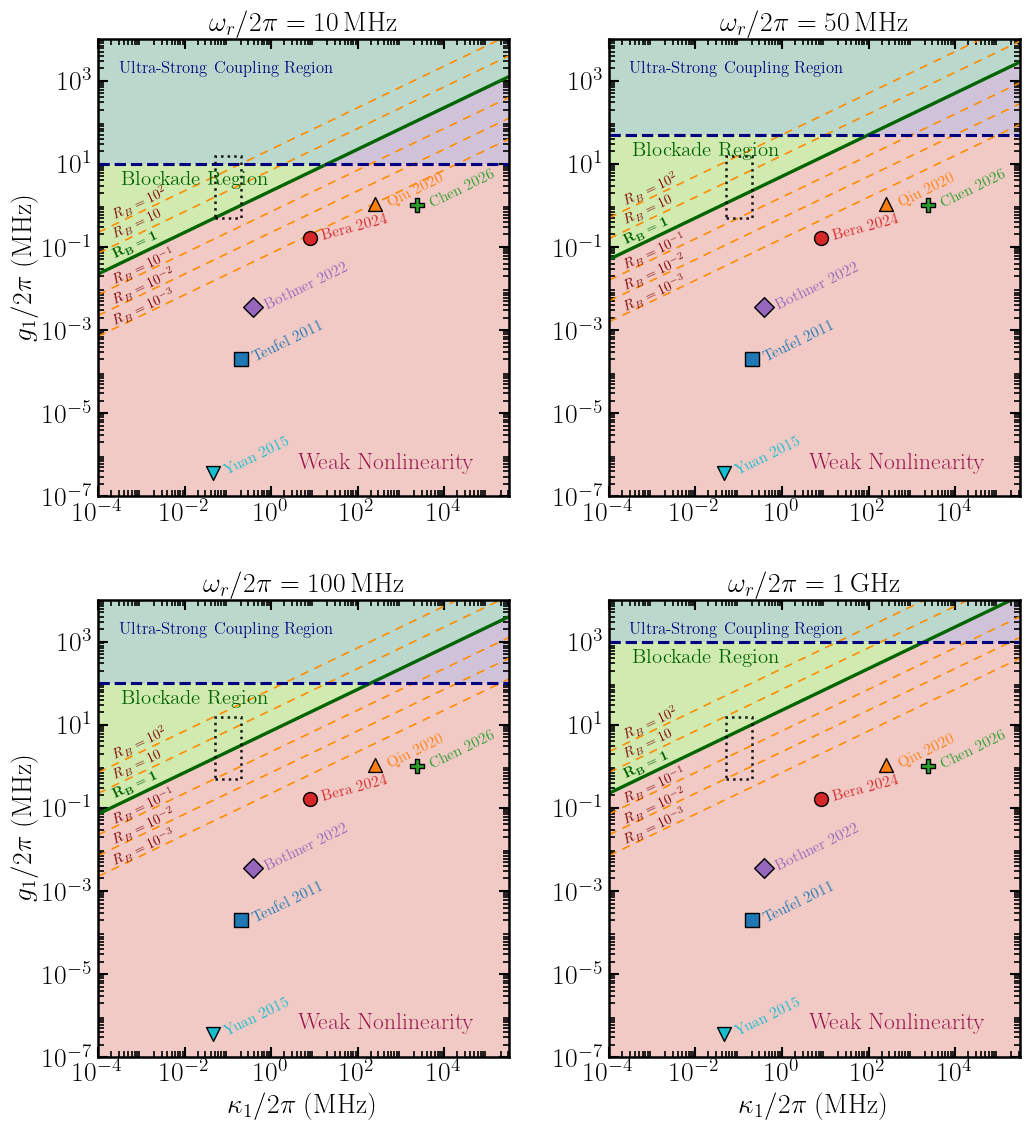

In [12]:
# ======================================================================================
# 4-panel version
# ======================================================================================
def plot_regime_diagram_4panels(save_fig=True):

    fig, axes = plt.subplots(2, 2, figsize=(11, 12))
    axes = axes.flatten()

    for i, (ax, omega_r) in enumerate(zip(axes, omega_r_list)):

        ratio_grid   = (2 * G_1**2 / omega_r) / KAPPA_1
        blockade     = ratio_grid > 1
        below_block  = ratio_grid < 1
        ultrastrong  = G_1 > omega_r

        ax.set_facecolor("#f4f1c4")

        ax.contourf(
            KAPPA_1, G_1, below_block.astype(float),
            levels=[0.5, 1.5],
            colors=["#efb0c9"],
            alpha=0.60
        )

        ax.contourf(
            KAPPA_1, G_1, blockade.astype(float),
            levels=[0.5, 1.5],
            colors=["#b8e6a3"],
            alpha=0.60
        )

        ax.contourf(
            KAPPA_1, G_1, ultrastrong.astype(float),
            levels=[0.5, 1.5],
            colors=["#93b7ff"],
            alpha=0.35
        )

        for R in ratio_values:
            g_line = g_from_ratio(kappa_1_list, omega_r, R)

            if np.any((g_line >= g_1_list.min()) & (g_line <= g_1_list.max())):
                if np.isclose(R, 1.0):
                    ax.plot(kappa_1_list, g_line, color="darkgreen", lw=2.4)
                else:
                    ax.plot(
                        kappa_1_list, g_line,
                        color="darkorange",
                        lw=1.2,
                        ls=(0, (5, 4))
                    )

        for region in chosen_regions:
            rect = mpatches.Rectangle(
                (region["kappa_min"], region["g_min"]),
                region["kappa_max"] - region["kappa_min"],
                region["g_max"] - region["g_min"],
                facecolor=region.get("facecolor"),
                edgecolor=region.get("edgecolor"),
                alpha=region.get("alpha"),
                linestyle=region.get("linestyle"),
                linewidth=region.get("linewidth"),
                zorder=8
            )

            ax.add_patch(rect)


        ax.axhline(omega_r, color="navy", lw=2.2, ls="--")

        place_regime_labels(
        ax=ax,
        omega_r=omega_r,
        kappa_1_list=kappa_1_list,
        g_1_list=g_1_list
        )

        ax.text(
            0.05, 0.95,
            "Ultra-Strong Coupling Region",
            transform=ax.transAxes,
            fontsize=12,
            color="navy",
            rotation=0,
            va="top"
        )

        #x_positions_for_labels = [1.5e-3, 4e-3, 1.3e-2, 4e-2, 1.5e-1, 5e-1]
        x_positions_for_labels = [2e-4, 2e-4, 2e-4,2e-4, 2e-4, 2e-4]
        #x_positions_for_labels = [9e-1, 10e-1, 11e-1, 14e-1, 13e-1, 13e-1]
        add_ratio_line_labels(
            ax=ax,
            omega_r=omega_r,
            ratio_values=ratio_values,
            x_positions=x_positions_for_labels
        )

        for point in chosen_points:
            ax.scatter(
                point["kappa_1"],
                point["g_1"],
                s=100,
                color=point.get("color", "black"),
                marker=point.get("marker", "o"),
                edgecolor="black",
                linewidth=1.0,
                zorder=10
            )

            ax.annotate(
                point["label"],
                xy=(point["kappa_1"], point["g_1"]),
                xytext=(7, -2),
                textcoords="offset points",
                fontsize=11,
                rotation=point.get("rotation", 26),
                color=point.get("color", "black"),
                zorder=11
            )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=5))
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))

        ax.xaxis.set_minor_locator(
            ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
        )
        ax.yaxis.set_minor_locator(
            ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
        )

        ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))

        ax.set_xlim(kappa_1_list.min(), kappa_1_list.max())
        ax.set_ylim(g_1_list.min(), g_1_list.max())

        ax.set_title(format_wr_title(omega_r), fontsize=20)
        # xlabel only for bottom row
        if i in [2, 3]:
            ax.set_xlabel(r"$\kappa_1/2\pi$ (MHz)", fontsize=20)
        else:
            ax.set_xlabel("")

        # ylabel only for left column
        if i in [0, 2]:
            ax.set_ylabel(r"$g_1/2\pi$ (MHz)", fontsize=20)
        else:
            ax.set_ylabel("")

        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            top=True,
            right=True,
            labelsize=20,
            length=7,
            width=1.5
        )

        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            top=True,
            right=True,
            labelsize=0,
            length=4,
            width=1.2
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

    ratio_handles = [
        mlines.Line2D([], [], color="maroon", lw=1.8, ls=(0, (8, 6)),
                      label=rf"$R_B={R:g}$")
        for R in ratio_values if not np.isclose(R, 1.0)
    ]
    boundary_handle = mlines.Line2D([], [], color="darkgreen", lw=2.4, label=r"$R_B=1$")
    ultra_handle = mlines.Line2D([], [], color="navy", lw=2.2, ls="--", label=r"$g_1=\omega_r$")
    point_handle = mlines.Line2D([], [], color="black", marker="o", linestyle="None",
                                 markersize=7, label="Our parameters")


    #fig.tight_layout(rect=[0, 0.08, 1, 1])
    fig.tight_layout()

    if save_fig:
        fig.savefig(os.path.join(save_folder, "regime_diagram_4panels_version3.png"), dpi=300)
        fig.savefig(os.path.join(save_folder, "regime_diagram_4panels_version3.pdf"), dpi=300)

    plt.show()

# ======================================================================================
# PLOT 4-PANEL REGIME DIAGRAM
# ======================================================================================
plot_regime_diagram_4panels()